# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Marek Rosberg
* Username: mrosberg
* Student number: S6200060
* Group (AS1, etc.): AS1

-----

In [ ]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

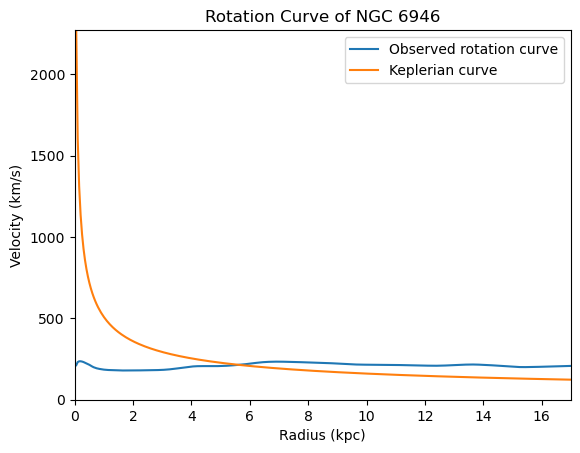

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G, parsec

#--stellar mass (example value, replace if given explicitly)---
Msun = 1.989e30
M = 6e10 * Msun

#------------------------load data-----------------------
r, v = np.loadtxt("rotcur.dat", usecols=(0,1), unpack=True)

mask = r > 0

r = r[mask]
v = v[mask] #Quick restriction I managed to find to make sure the values won't reach 1/0 (undefined)

#-------------------convert radius kpc to metres---------------
r_m = r * 1000 * parsec

#------------------------keplerian velocity----------------
v_kepler = np.sqrt(G*M/r_m)

#------------------------convert m/s to km/s---------------
v_kepler = v_kepler / 1000

#------------------------save curve----------------------------
np.savetxt("keplerian_curve.txt", np.column_stack((r, v_kepler)))

#------------------load saved curve---------------------
rk, vk = np.loadtxt("keplerian_curve.txt", unpack=True)

#---------------------plot--------------------------
plt.plot(r, v, label="Observed rotation curve")
plt.plot(rk, vk, label="Keplerian curve")

plt.xlabel("Radius (kpc)")
plt.ylabel("Velocity (km/s)")
plt.title("Rotation Curve of NGC 6946")

plt.xlim(0, rk.max())
plt.ylim(0, vk.max())

plt.legend()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

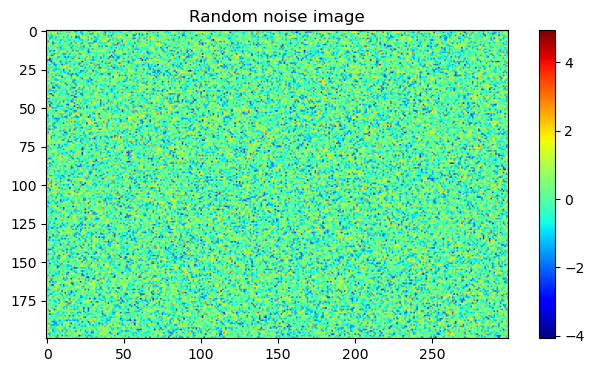

Slice mean: 0.031182527994454395
Slice std: 1.0010480103949222


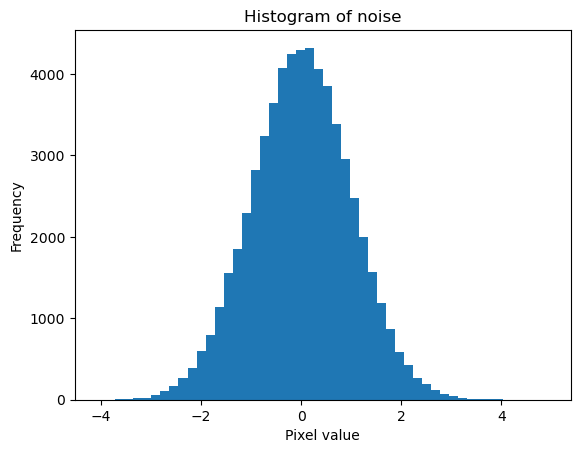

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#------------------create image-------------------
img = np.random.normal(0, 1.0, (200,300))

plt.figure(figsize=(8,4))
plt.imshow(img, cmap='jet')
plt.colorbar()
plt.title("Random noise image")
plt.show()

#-----------------slice-------------------------
slice_img = img[50:80, 100:130]

mean_val = slice_img.mean()
std_val = slice_img.std()

print("Slice mean:", mean_val)
print("Slice std:", std_val)

#---------------------histogram----------------
plt.figure()
plt.hist(img.ravel(), bins=50)
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.title("Histogram of noise")
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

Area: 18.84955592153876
Perimeter: 15.865439589251233
AstroEllipse(center=(0,0), a=3.0, b=2.0, angle=0)


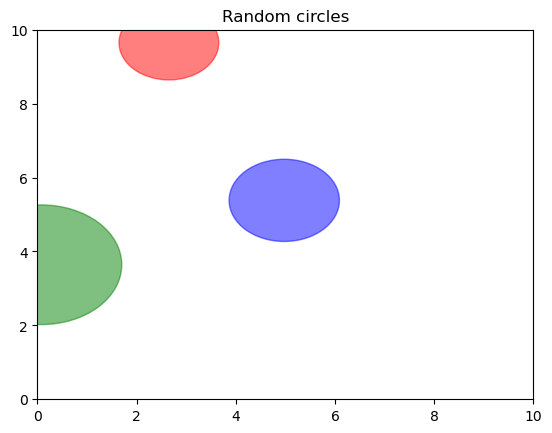

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

#--------------Copied code from the manual -----

class AstroEllipse(Ellipse):
   def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees

      assert(semi_major >= semi_minor)

      XY = (xc, yc)
      angle_mpl = position_angle
      height = 2.0 * semi_major
      width  = 2.0 * semi_minor

      super().__init__(XY, width, height, angle=angle_mpl, **args)

#--------------------New code-----------------

   def area(self):
      a = self.height / 2
      b = self.width / 2
      return np.pi * a * b

   def perimeter(self):
      a = self.height / 2
      b = self.width / 2
      h = ((a - b)**2) / ((a + b)**2)
      return np.pi*(a+b)*(1 + (3*h)/(10 + np.sqrt(4 - 3*h)))

   def __str__(self):
      xc, yc = self.center
      a = self.height / 2
      b = self.width / 2
      return f"AstroEllipse(center=({xc},{yc}), a={a}, b={b}, angle={self.angle})"


# ---------------Area of an Ellipse--------------

ellipse = AstroEllipse(0, 0, 3, 2, 0)

print("Area:", ellipse.area())
print("Perimeter:", ellipse.perimeter())
print(ellipse)


# ----------Circle class inheriting from AstroEllipse------------

class MyCircle(AstroEllipse):

   def __init__(self, xc, yc, radius, **args):
      super().__init__(xc, yc, radius, radius, 0, **args)


# --------------Plot three random circles---------------

fig, ax = plt.subplots()

colors = ["red", "blue", "green"]

for i in range(3):

   xc = np.random.uniform(0,10)
   yc = np.random.uniform(0,10)
   r = np.random.uniform(0.5,2)

   circle = MyCircle(xc, yc, r, color=colors[i], alpha=0.5)

   ax.add_patch(circle)

ax.set_xlim(0,10)
ax.set_ylim(0,10)

plt.title("Random circles")
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

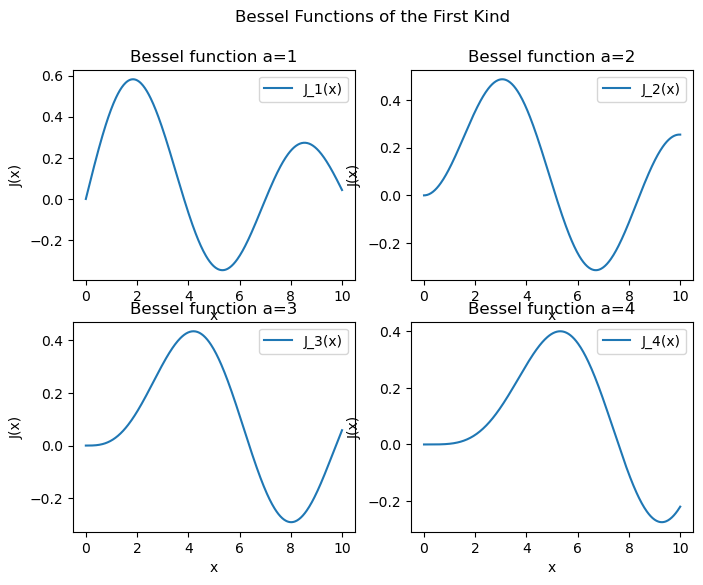

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

x = np.linspace(0,10,400)

fig, axs = plt.subplots(2,2, figsize=(8,6))
#Created as 4 small plots instead of 1 capital plot
orders = [1,2,3,4]

#--------------------Restrictions of the functions--------------------
for ax, a in zip(axs.ravel(), orders):

    y = jv(a, x)

    ax.plot(x, y, label=f"J_{a}(x)")
    ax.set_xlabel("x")
    ax.set_ylabel("J(x)")
    ax.set_title(f"Bessel function a={a}")
    ax.legend()

fig.suptitle("Bessel Functions of the First Kind")

plt.savefig("bessel.png", transparent=True)

plt.show()

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

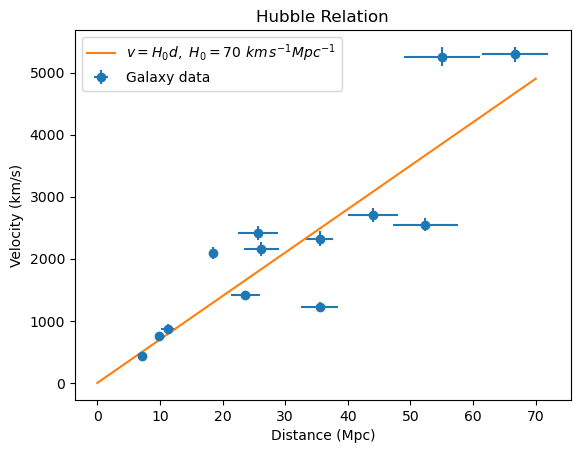

In [5]:
import numpy as np
import matplotlib.pyplot as plt

data = np.array([
18.49,2094.75,0.3,100,
35.48,2320.87,2.2,120,
35.48,1224.9,3.0,80,
11.34,872.13,1.2,80,
7.12,432.2,0.4,70,
9.82,751,0.3,75,
23.66,1410,2.3,70,
44,2700,4.0,110,
66.7,5292,5.3,120,
52.4,2550,5.2,100,
55,5253,6.1,150,
25.6,2419,3.2,110,
26.19,2158,2.8,110
])

#-------------------------Data------------------------------
d = data[0::4]
v = data[1::4]
d_err = data[2::4]
v_err = data[3::4]

H0 = 70

#-----------------------------Plot------------------------
fig, ax = plt.subplots()

ax.errorbar(d, v, xerr=d_err, yerr=v_err,
            fmt='o', label="Galaxy data")

x = np.linspace(0,70,100)
ax.plot(x, H0*x, label=r"$v = H_0 d,\ H_0=70\ km\,s^{-1}Mpc^{-1}$")

ax.set_xlabel("Distance (Mpc)")
ax.set_ylabel("Velocity (km/s)")
ax.set_title("Hubble Relation")

ax.legend()

plt.show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")